In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
tf.keras.utils.set_random_seed(12)

batch_size = 32
img_height = img_width =224

In [3]:
directory = "dataset/train"
test = "dataset/valid"

In [4]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    directory,
    labels="inferred",
    label_mode="binary",
    #class_names=None,
    shuffle=True,
    seed=12,
    validation_split= 0.15,
    subset="training",
    image_size=(img_height, img_width),
    batch_size=batch_size)

Found 1924 files belonging to 2 classes.
Using 1636 files for training.


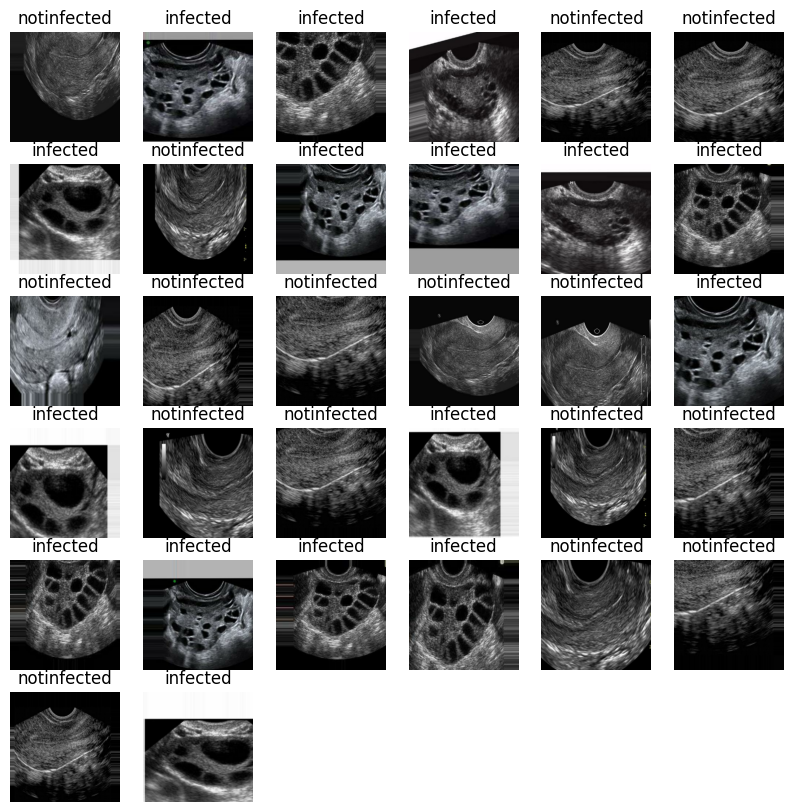

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
class_names = train_ds.class_names
for images, labels in train_ds.take(2):
    for i in range(32):
        ax = plt.subplot(6, 6, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale = 1./255,
                             shear_range = 0.2,
                             zoom_range = 0.2,
                             #width_shift_range=0.2,
                             #height_shift_range=0.2,
                             horizontal_flip = True,
                             vertical_flip=True,
                             rotation_range=20,
                             validation_split=0.2,
                             fill_mode='nearest'
                             )
# prepare an iterators for each dataset
train_ds = datagen.flow_from_directory(directory,
                                       class_mode='categorical',
                                       classes=['infected', 'notinfected'],
                                       target_size=(224, 224),
                                       batch_size=batch_size,
                                       subset='training',
                                       seed=12)
# prepare an iterators for each dataset
val_ds = datagen.flow_from_directory( directory,
                                      class_mode='categorical',
                                      classes=['infected', 'notinfected'],
                                      target_size=(224, 224),
                                      batch_size=batch_size,
                                      subset='validation',
                                      seed=12)

Found 1540 images belonging to 2 classes.
Found 384 images belonging to 2 classes.


In [7]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test,
    seed=12,
    image_size=(img_height, img_width),
    batch_size=batch_size)

Found 1932 files belonging to 2 classes.


In [8]:
model = Sequential()
 
model.add(Conv2D(12, (5,5), padding='SAME', activation='relu', input_shape=(img_height, img_width, 3)))
model.add(MaxPooling2D(pool_size=(2,2)))
#model.add(Dropout(0.1))

model.add(Conv2D(8, (5,5),padding='SAME',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
#model.add(Dropout(0.1))

model.add(Conv2D(4, (5,5),padding='SAME',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())

model.add(Dense(2,activation='softmax'))

opt=Adam(learning_rate=0.01)
model.compile(optimizer=opt, loss=BinaryCrossentropy(), metrics=['accuracy'])

In [9]:
earlyStopping = EarlyStopping(monitor="val_loss", mode="min", verbose=1,patience=15)

In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    callbacks=[earlyStopping],
    batch_size=batch_size,
    verbose=1,
    epochs=20)

Epoch 1/20
49/49 [==============================] - 95s 2s/step - loss: 0.5074 - accuracy: 0.7545 - val_loss: 0.2663 - val_accuracy: 0.8828
Epoch 2/20
49/49 [==============================] - 81s 2s/step - loss: 0.1512 - accuracy: 0.9351 - val_loss: 0.0657 - val_accuracy: 0.9818
Epoch 3/20
49/49 [==============================] - 86s 2s/step - loss: 0.0898 - accuracy: 0.9695 - val_loss: 0.0741 - val_accuracy: 0.9714
Epoch 4/20
49/49 [==============================] - 88s 2s/step - loss: 0.0531 - accuracy: 0.9831 - val_loss: 0.0166 - val_accuracy: 1.0000
Epoch 5/20
49/49 [==============================] - 84s 2s/step - loss: 0.0132 - accuracy: 0.9955 - val_loss: 0.0235 - val_accuracy: 0.9870
Epoch 6/20
49/49 [==============================] - 88s 2s/step - loss: 0.0176 - accuracy: 0.9929 - val_loss: 0.0159 - val_accuracy: 0.9948
Epoch 7/20
49/49 [==============================] - 83s 2s/step - loss: 0.0416 - accuracy: 0.9844 - val_loss: 0.0209 - val_accuracy: 0.9896
Epoch 8/20
49/49 [==

In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 12)      912       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 12)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 8)       2408      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 56, 56, 8)        0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 56, 56, 4)         804       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 28, 28, 4)        0

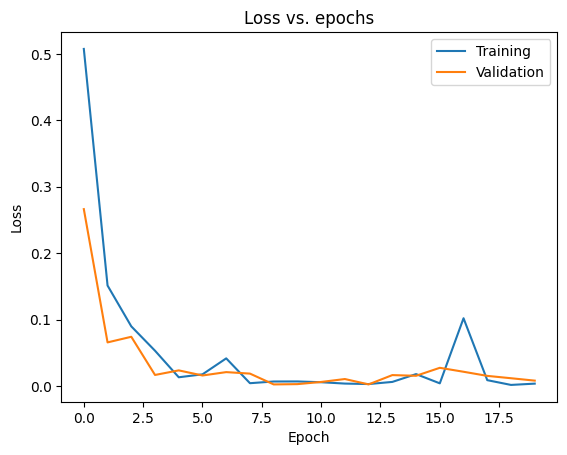

In [12]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()

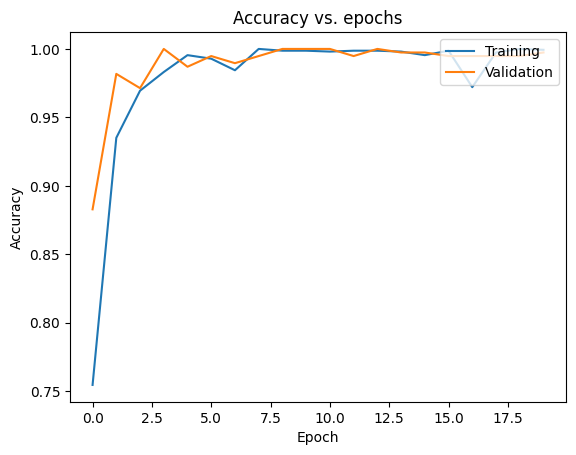

In [13]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy vs. epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()

In [14]:
model.evaluate(val_ds)

12/12 [==============================] - 5s 442ms/step - loss: 0.0044 - accuracy: 1.0000


[0.004380641970783472, 1.0]

In [15]:
model.save('image_model.keras')